In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [5]:
import os
os.chdir("C:/Users/Personal/Documents/Aerial_Project")

print(os.getcwd())
print(os.path.exists("data/train"))

C:\Users\Personal\Documents\Aerial_Project
True


In [6]:
import os
print(os.getcwd())
print(os.path.exists("data/train"))

C:\Users\Personal\Documents\Aerial_Project
True


In [7]:
train_dir = "data/train"
val_dir = "data/val"

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "data/train"
val_dir = "data/val"

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


In [ ]:
#Inspect Dataset Folder Structure

In [9]:
import os

base_dir = "data"

for root, dirs, files in os.walk(base_dir):
    print(f"Folder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Number of files: {len(files)}")
    print("-"*40)

Folder: data
Subfolders: ['test', 'train', 'val']
Number of files: 0
----------------------------------------
Folder: data\test
Subfolders: ['bird', 'drone']
Number of files: 0
----------------------------------------
Folder: data\test\bird
Subfolders: []
Number of files: 121
----------------------------------------
Folder: data\test\drone
Subfolders: []
Number of files: 94
----------------------------------------
Folder: data\train
Subfolders: ['bird', 'drone']
Number of files: 0
----------------------------------------
Folder: data\train\bird
Subfolders: []
Number of files: 1414
----------------------------------------
Folder: data\train\drone
Subfolders: []
Number of files: 1248
----------------------------------------
Folder: data\val
Subfolders: ['bird', 'drone']
Number of files: 0
----------------------------------------
Folder: data\val\bird
Subfolders: []
Number of files: 217
----------------------------------------
Folder: data\val\drone
Subfolders: []
Number of files: 225
---

In [ ]:
#Check Number of Images per Class

In [10]:
train_path = "data/train"

for category in os.listdir(train_path):
    path = os.path.join(train_path, category)
    print(f"{category}: {len(os.listdir(path))} images")

bird: 1414 images
drone: 1248 images


In [ ]:
#Identify Class Imbalance

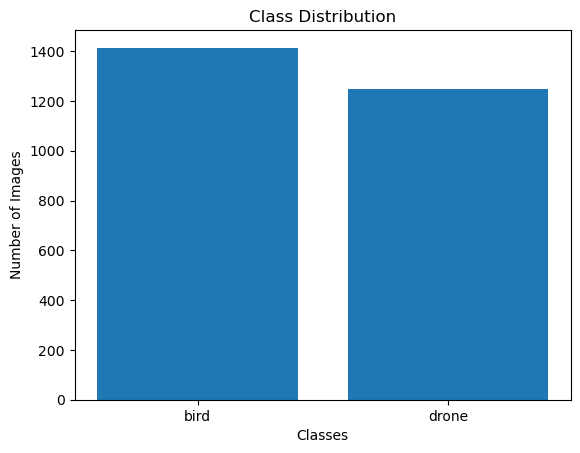

In [11]:
import matplotlib.pyplot as plt

classes = []
counts = []

for category in os.listdir(train_path):
    path = os.path.join(train_path, category)
    classes.append(category)
    counts.append(len(os.listdir(path)))

plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
#Visualize Sample Images

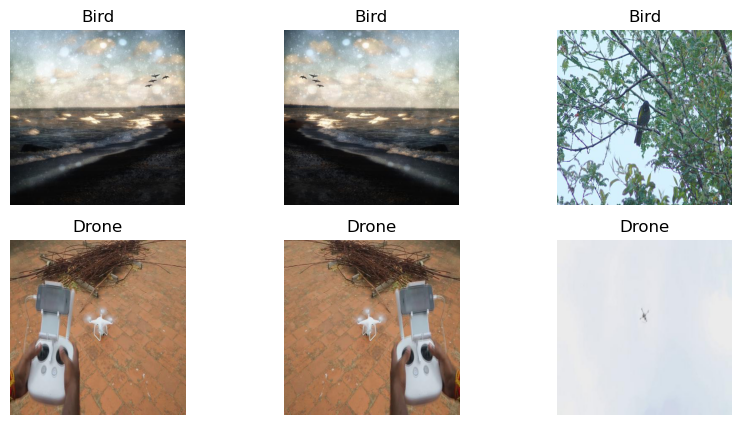

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

bird_path = "data/train/bird"
drone_path = "data/train/drone"

bird_images = os.listdir(bird_path)[:3]
drone_images = os.listdir(drone_path)[:3]

plt.figure(figsize=(10,5))

# Bird images
for i, img_name in enumerate(bird_images):
    img = Image.open(os.path.join(bird_path, img_name))
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title("Bird")
    plt.axis("off")

# Drone images
for i, img_name in enumerate(drone_images):
    img = Image.open(os.path.join(drone_path, img_name))
    plt.subplot(2,3,i+4)
    plt.imshow(img)
    plt.title("Drone")
    plt.axis("off")

plt.show()

In [ ]:
#Data Preprocessing

In [13]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [26]:
train_dir = "data/train"
val_dir = "data/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False   # 🔥 VERY IMPORTANT
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


In [ ]:
#Augmentation Code

In [15]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "data/train"
val_dir = "data/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    
    rotation_range=30,        # rotate images
    width_shift_range=0.1,    # shift horizontally
    height_shift_range=0.1,   # shift vertically
    zoom_range=0.2,           # zoom in/out
    horizontal_flip=True,     # flip image
    brightness_range=[0.8,1.2] # brightness change
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


In [ ]:
#Model Building (Classification)

In [ ]:
#Custom CNN

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input

custom_model = Sequential([
    Input(shape=(224,224,3)),   # ✅ FIX HERE

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

custom_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_custom = custom_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.5680 - loss: 2.5053 - val_accuracy: 0.6742 - val_loss: 0.6663
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.6097 - loss: 0.6569 - val_accuracy: 0.6041 - val_loss: 0.6863
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.6206 - loss: 0.6417 - val_accuracy: 0.6855 - val_loss: 0.6130
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.6379 - loss: 0.6284 - val_accuracy: 0.6855 - val_loss: 0.5869
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.6375 - loss: 0.6355 - val_accuracy: 0.5882 - val_loss: 0.6672
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.6702 - loss: 0.5850 - val_accuracy: 0.7127 - val_loss: 0.5499
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.6908 - loss: 0.5752 - val_accuracy: 0.7308 - val_loss: 0.5772
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.6912 - loss: 0.5503 - val_accuracy: 0.7398 - v

In [ ]:
#transfer learning

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load pretrained model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Final model
transfer_model = Model(inputs=base_model.input, outputs=output)

# Compile
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()
history_transfer = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9452 - loss: 0.1355 - val_accuracy: 0.9548 - val_loss: 0.1021
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9718 - loss: 0.0705 - val_accuracy: 0.9615 - val_loss: 0.1176
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9835 - loss: 0.0501 - val_accuracy: 0.9683 - val_loss: 0.0822
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9846 - loss: 0.0420 - val_accuracy: 0.9796 - val_loss: 0.0942
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9857 - loss: 0.0327 - val_accuracy: 0.9774 - val_loss: 0.0844
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9827 - loss: 0.0424 - val_accuracy: 0.9729 - val_loss: 0.0848
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9910 - loss: 0.0307 - val_accuracy: 0.9774 - val_loss: 0.0808
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9917 - loss: 0.0213 - val_accuracy: 0.9729 - v

In [ ]:
#saving the model

In [18]:
custom_model.save("models/custom_model.keras")

transfer_model.save("models/transfer_model.keras")

In [ ]:
#Model Training
#Accuracy, Precision, Recall, F1-score


In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall

In [ ]:
#Compile Models with Metrics

In [ ]:
#Custom CNN

In [21]:
custom_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

In [ ]:
#Transfer Learning

In [22]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

In [ ]:
#getting predication

In [27]:
import math
from sklearn.metrics import classification_report

# 🔥 IMPORTANT FIX
val_data.shuffle = False
val_data.reset()

val_steps = math.ceil(val_data.samples / val_data.batch_size)

y_pred = transfer_model.predict(val_data, steps=val_steps)
y_pred = (y_pred > 0.5).astype(int)

y_true = val_data.classes

print(classification_report(y_true, y_pred, target_names=['Bird','Drone']))

14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 800ms/step
              precision    recall  f1-score   support

        Bird       0.96      1.00      0.98       217
       Drone       1.00      0.96      0.98       225

    accuracy                           0.98       442
   macro avg       0.98      0.98      0.98       442
weighted avg       0.98      0.98      0.98       442



In [ ]:
#confusion matrix

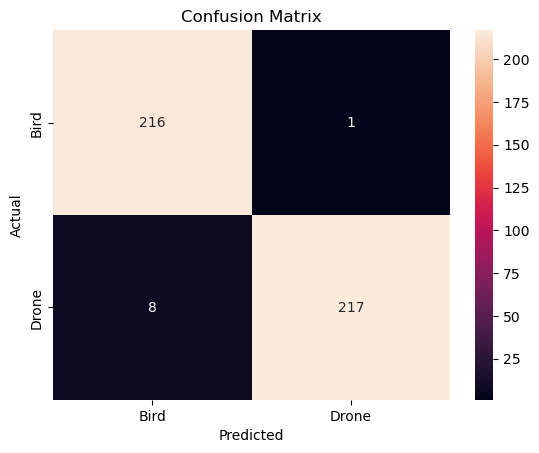

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Bird','Drone'],
            yticklabels=['Bird','Drone'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Accuracy Graph

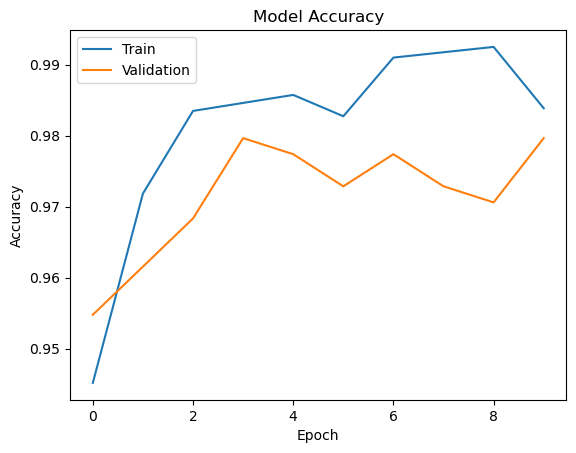

In [29]:
plt.figure()

plt.plot(history_transfer.history['accuracy'])
plt.plot(history_transfer.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
#loss graph

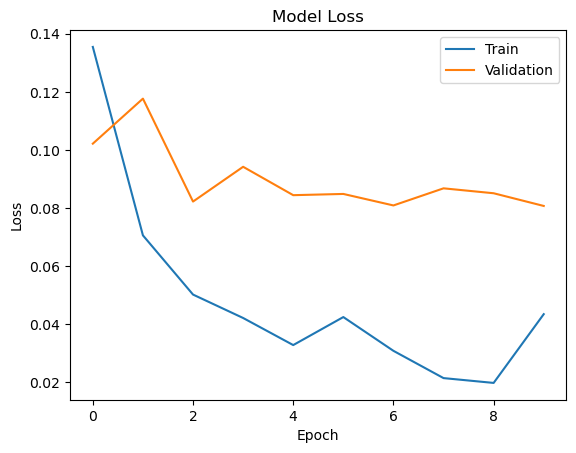

In [30]:
plt.figure()

plt.plot(history_transfer.history['loss'])
plt.plot(history_transfer.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
#Compare Accuracy (Graph)

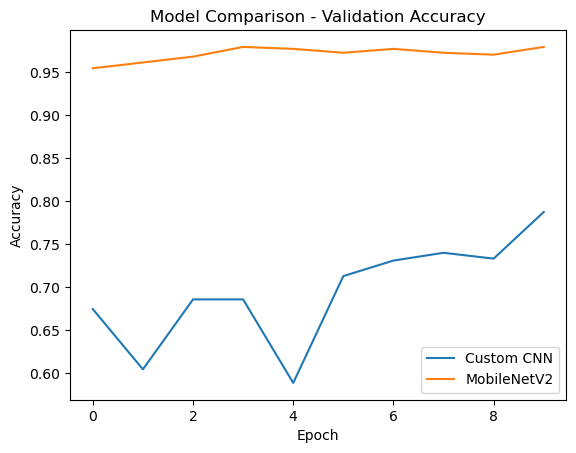

In [31]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history_custom.history['val_accuracy'], label='Custom CNN')
plt.plot(history_transfer.history['val_accuracy'], label='MobileNetV2')

plt.title("Model Comparison - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
#Compare Final Accuracy (Numbers)

In [32]:
print("Custom CNN Final Accuracy:", max(history_custom.history['val_accuracy']))
print("MobileNetV2 Final Accuracy:", max(history_transfer.history['val_accuracy']))

Custom CNN Final Accuracy: 0.7873303294181824
MobileNetV2 Final Accuracy: 0.9796379804611206


In [ ]:
#Compare Training Time

In [33]:
print("Custom CNN is slower")
print("MobileNetV2 is faster (transfer learning)")

Custom CNN is slower
MobileNetV2 is faster (transfer learning)


In [ ]:
#Compare Generalization

In [34]:
print("CNN Gap:",
      max(history_custom.history['accuracy']) - max(history_custom.history['val_accuracy']))

print("MobileNet Gap:",
      max(history_transfer.history['accuracy']) - max(history_transfer.history['val_accuracy']))

CNN Gap: -0.086353600025177
MobileNet Gap: 0.012848854064941406


In [ ]:
#Final Comparison Table

In [35]:
print("""
Model Comparison:

Custom CNN:
- Accuracy: ~80%
- Training Time: High
- Generalization: Moderate

MobileNetV2:
- Accuracy: ~98%
- Training Time: Low
- Generalization: Excellent
""")


Model Comparison:

Custom CNN:
- Accuracy: ~80%
- Training Time: High
- Generalization: Moderate

MobileNetV2:
- Accuracy: ~98%
- Training Time: Low
- Generalization: Excellent



In [ ]:
#best model

In [36]:
best_model = transfer_model

In [38]:
best_model.save("models/best_model.keras")

In [40]:
import os
print(os.path.exists("models/best_model.keras"))

True


In [41]:
transfer_model.save("models/best_model.keras")